### General Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os, torch, datetime, time
import numpy as np
sys.path.append("..")
import rfi_ml_s4
import matplotlib.pyplot as plt

In [2]:
print(f"Is CUDA supported by this system?{torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

Is CUDA supported by this system?True
CUDA version: 12.1


### Loading Data

In [3]:
# Downloading from main drive (Windows)

train_dir='C:/MLdatasets/f150_data/train_data'
eval_dir='C:/MLdatasets/f150_data/eval_data'

# Downloading from external drive

#train_dir='D:/MLdatasets/s4data/train_data'
#eval_dir='D:/MLdatasets/s4data/eval_data'

### Visualizing Raw Training Data (make st. random files are pulled from training set, do later)

In [4]:
#fig, ax = plt.subplots(ncols=3, nrows=3, figsize=(15,15))

#for tod in 

### Setting Up Data for Training and Testing

In [5]:
Nepochs = 25 # Number of training epochs
Np = 2**10 # Defining chunk size, 1024 points is the default
hidden_dim = 2**10 # Should be size of dataset
hidden_dim_2 = hidden_dim
z_dim = 4 # Size of squeeze point
dropout = 0.2 # Dropout for training
Nfft = Np // 2 + 1

freq = 'f150' # Setting frequency channel

In [6]:
start_time = time.time()

s = rfi_ml_s4.S4Loader(Np=Np, freq=freq) # Calling S4 loader class defined in directory above

train_data = s.loadData(data_dir=train_dir, test=False) # Loading training dataset

eval_data = s.loadData(data_dir=eval_dir, test=False) # Loading evaluation dataset

train_data, eval_data = s.normalizeData(train_data, eval_data) #normalizing data, checking

Data dir: C:/MLdatasets/f150_data/train_data/**/*_f150.npy
Data Loaded!
Size:  (64159, 1024)
Data dir: C:/MLdatasets/f150_data/eval_data/**/*_f150.npy
Data Loaded!
Size:  (37104, 1024)
Train data mean:  1.9303585245988856e-13
Eval data mean:  -1.744950789199556e-15
RMS normalization factor:  0.04082740809775888


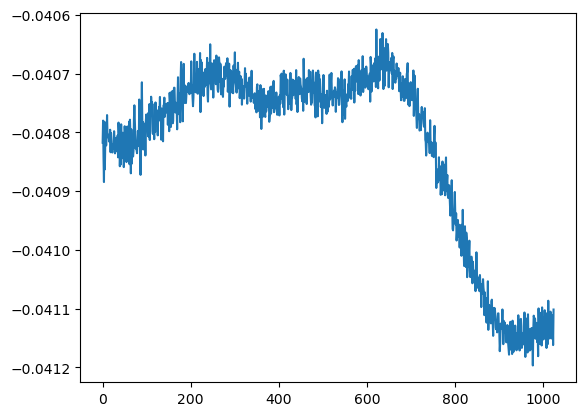

In [7]:
plt.plot(train_data[100])

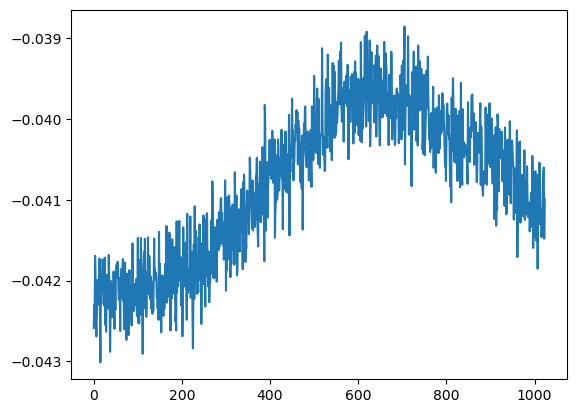

In [8]:
plt.plot(eval_data[100])

### Training and Testing

In [9]:
call = rfi_ml_s4.RFIDetect(Np, Nepochs = Nepochs, # Calling RFIDetect class from rfi_ml_s4
                             z_dim = z_dim, hidden_dim = hidden_dim, 
                           hidden_dim_2 = hidden_dim_2,
                          dropout=dropout) 

In [10]:
call.train(train_data) # Training the NN
del train_data # Aaaaaand for some reason we're deleting the data, something I didn't notice before apparently

[  0/25][  0/2004]	Loss: 0.0020617775
[  0/25][100/2004]	Loss: 0.0000011671
[  0/25][200/2004]	Loss: 0.0000011222
[  0/25][300/2004]	Loss: 0.0000008217
[  0/25][400/2004]	Loss: 0.0000004015
[  0/25][500/2004]	Loss: 0.0000009940
[  0/25][600/2004]	Loss: 0.0000004003
[  0/25][700/2004]	Loss: 0.0000001486
[  0/25][800/2004]	Loss: 0.0000001138
[  0/25][900/2004]	Loss: 0.0000004990
[  0/25][1000/2004]	Loss: 0.0017409357
[  0/25][1100/2004]	Loss: 0.0000008325
[  0/25][1200/2004]	Loss: 0.0000006545
[  0/25][1300/2004]	Loss: 0.0000006348
[  0/25][1400/2004]	Loss: 0.0000002509
[  0/25][1500/2004]	Loss: 0.0000006689
[  0/25][1600/2004]	Loss: 0.0000002328
[  0/25][1700/2004]	Loss: 0.0000003087
[  0/25][1800/2004]	Loss: 0.0000001980
[  0/25][1900/2004]	Loss: 0.0000003602
[  0/25][2000/2004]	Loss: 0.0000002511
[  1/25][ 96/2004]	Loss: 0.0000001801
[  1/25][196/2004]	Loss: 0.0000001605
[  1/25][296/2004]	Loss: 0.0000002126
[  1/25][396/2004]	Loss: 0.0000001662
[  1/25][496/2004]	Loss: 0.0000001407
[

In [11]:
start_test = time.time()
rfi_recov = call.evaluate(eval_data) # Evaluating the NN
end_test = time.time()

Epochs:  25
N tests:  37104
Length of timestream:  1024
Input Timestream RMS:  [0.00097465 0.00133717 0.00132352 ... 0.00178351 0.00215739 0.00139924]
Avg RMS for all tests:  0.001295403 



Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_0.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_1.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_2.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_3.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_4.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_5.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_6.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_7.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_8.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_9.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_10.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_11.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_12.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_13.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_14.png
Saving file...rfi_ml/2024-07-31_15-48-50_contrast_test_15.png
Saving file...rfi_

KeyboardInterrupt: 

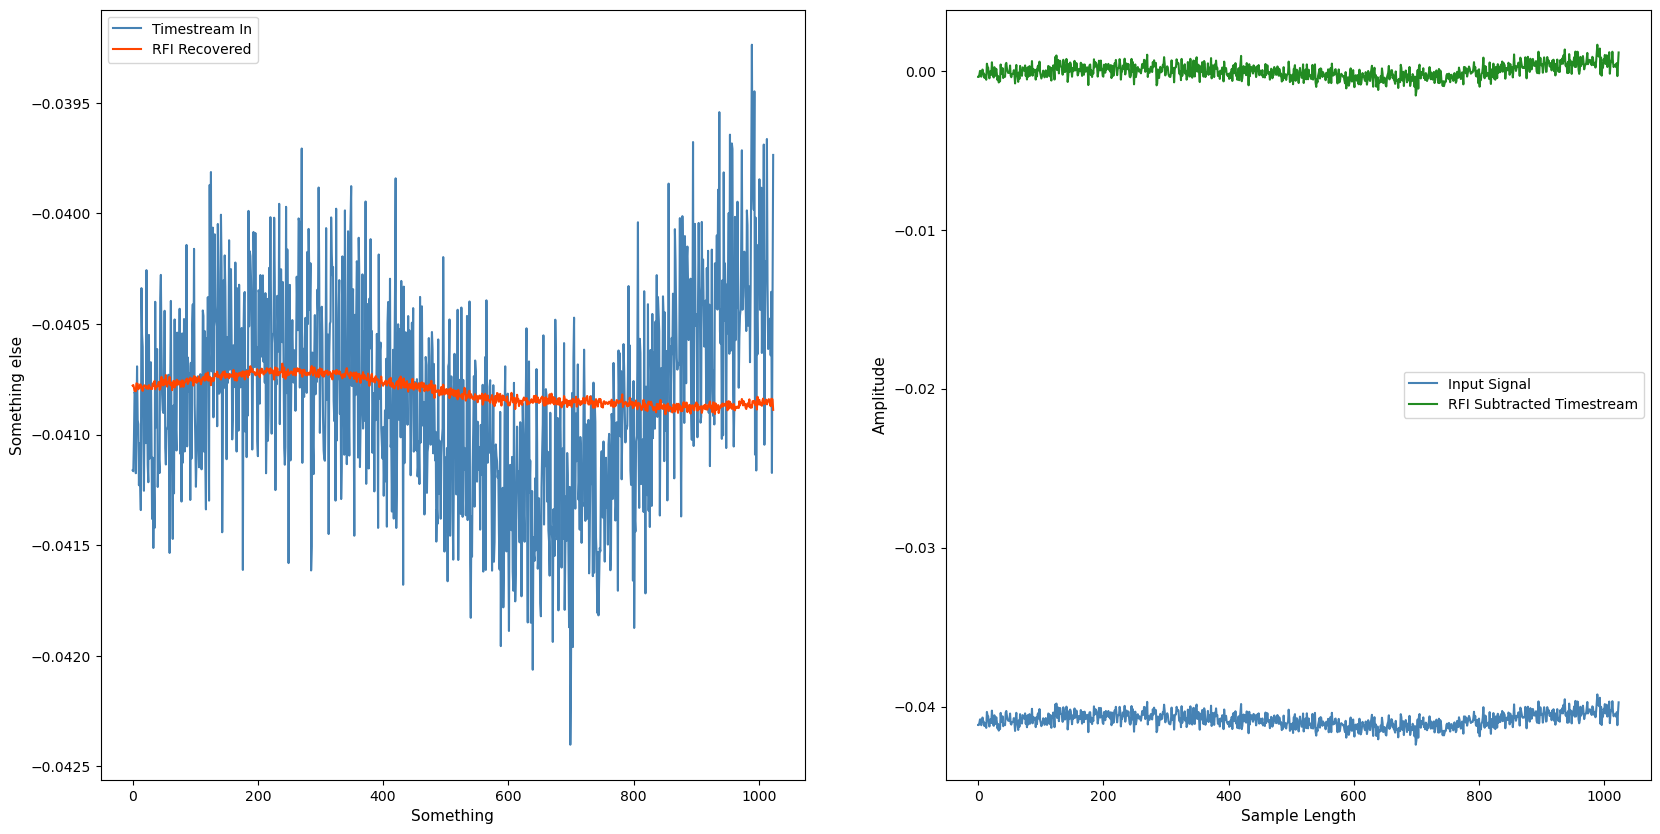

In [12]:
call.plot_eval(rfi_recov, eval_data) # Plotting the results

In [ ]:
print("Runtime: ", time.time()-start_time)
print("Evaltime: ", end_test-start_test)